# Spotify long tracks — duration tail EDA (2014–2024)

Dataset: [aminasalamt/sfotyeyjgh-dataet](https://www.kaggle.com/datasets/aminasalamt/sfotyeyjgh-dataet).

**Grain:** one row per **track** (`816` rows, `4` columns). Fields: Spotify `ID`, track `Name`, `Duration (Minutes)`, and `Artists`.

This slice is **skewed toward longer recordings** (ambient, classical, devotional, nature soundscapes). Use the notebook for **catalog composition and outliers**, not as a representative sample of all Spotify streaming behavior.

**Objective:** characterize the **duration distribution**, define “long” tiers (aligned with ~14.5+ minute bin edges), and relate **artist concentration** to the long tail.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import kagglehub
import matplotlib.font_manager as fm
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)


def configure_matplotlib_fonts() -> None:
    preferred = (
        "PingFang SC",
        "PingFang HK",
        "Hiragino Sans GB",
        "Hiragino Sans",
        "Arial Unicode MS",
        "Noto Sans CJK JP",
        "Noto Sans CJK SC",
        "Apple SD Gothic Neo",
        "DejaVu Sans",
    )
    avail = {f.name for f in fm.fontManager.ttflist}
    chain = [n for n in preferred if n in avail]
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = chain + [
        x for x in plt.rcParams["font.sans-serif"] if x not in chain
    ]
    plt.rcParams["axes.unicode_minus"] = False


configure_matplotlib_fonts()


def resolve_wordcloud_font_path() -> str:
    for name in (
        "PingFang SC",
        "PingFang HK",
        "Hiragino Sans GB",
        "Arial Unicode MS",
        "Noto Sans CJK JP",
    ):
        try:
            path = fm.findfont(fm.FontProperties(family=name))
            if path and Path(path).exists():
                return path
        except ValueError:
            continue
    return fm.findfont(fm.FontProperties())


EXPECTED_COLS = ["ID", "Name", "Duration (Minutes)", "Artists"]
EXPECTED_ROWS = 816


def resolve_csv_path() -> Path:
    cols = set(EXPECTED_COLS)

    def sniff_match(path: Path) -> bool:
        h = pd.read_csv(path, nrows=0)
        return cols <= set(h.columns)

    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        candidates = sorted(kaggle_root.rglob("*.csv"))
        assert candidates, "no csv under /kaggle/input"
        for p in candidates:
            if sniff_match(p):
                return p
        raise AssertionError(f"no csv with columns {EXPECTED_COLS} under /kaggle/input")

    local = Path("data") / "spotify_long_tracks.csv"
    if local.exists():
        assert sniff_match(local), local
        return local

    root = Path(kagglehub.dataset_download("aminasalamt/sfotyeyjgh-dataet"))
    csvs = sorted(root.rglob("*.csv"))
    assert len(csvs) == 1, f"expected exactly one csv under {root}, got {csvs}"
    assert sniff_match(csvs[0]), csvs[0]
    return csvs[0]


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
extra = set(df.columns) - set(EXPECTED_COLS)
assert not extra, f"unexpected columns: {sorted(extra)}"
assert df.shape[0] == EXPECTED_ROWS, df.shape
assert df.shape[1] == len(EXPECTED_COLS)
assert pd.api.types.is_numeric_dtype(df["Duration (Minutes)"]), "Duration must be numeric"

dur = df["Duration (Minutes)"]
assert dur.notna().all(), "missing durations"

print(df.shape[0], "rows ×", df.shape[1], "cols")
display(df.sample(5, random_state=7))
display(df.dtypes)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CSV: /Users/nicapotato/.cache/kagglehub/datasets/aminasalamt/sfotyeyjgh-dataet/versions/1/spotify_long_tracks_2014_2024 (1).csv
816 rows × 4 cols


,ID,Name,Duration (Minutes),Artists
595,1Ej7djF5ihCOBc5HUY4Brf,Flute Concerto in D Major: I. Allegro,5,"Giacinto Schiatti, Raffaele Trevisani, Ensembl..."
397,4mfhiToz6a0po7hlVLDzE5,A Message for Mobley,6,Bob Reynolds
327,6yL1mRXYVn7OL4kVXKuS4B,The Last Hippie,6,Training Motivation Music
278,2BGqouLeX1GkjLeFuDfB7T,"Suite (From ""El Hombre Esponja"")",6,Fernando Velázquez
264,2DgMPjsAJsroCKGwj1EQG5,Totem - Extended Mix,6,"Lightform, Zaa"


ID                      str
Name                    str
Duration (Minutes)    int64
Artists                 str
dtype: object

## 1 — Univariate: duration distribution

**Agent summary (after running):** Report mean/median, quantiles, counts above **14.5 min** (“extended”) and **24 min** (“very long”), and the single longest track. Vertical lines mark those thresholds on the histogram.


Duration (minutes) quantiles:
 0.00      5.0
0.10      5.0
0.25      5.0
0.50      6.0
0.75      7.0
0.90      8.5
1.00    100.0

count >= 14.5: 32
count >= 24.0: 17
max duration: 100.0 min: 5.0


Matplotlib is building the font cache; this may take a moment.


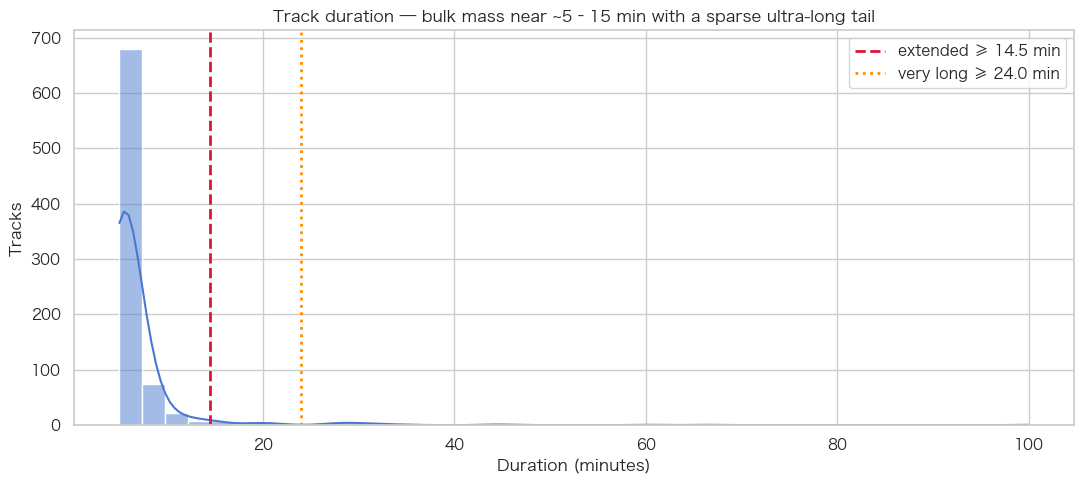

In [2]:
dur = df["Duration (Minutes)"]
qs = dur.quantile([0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
print("Duration (minutes) quantiles:\n", qs.to_string())
print("\ncount >= 14.5:", int((dur >= 14.5).sum()))
print("count >= 24.0:", int((dur >= 24.0).sum()))
print("max duration:", float(dur.max()), "min:", float(dur.min()))

THRESH_EXT = 14.5
THRESH_VLONG = 24.0

fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(dur, bins=40, kde=True, ax=ax, color=sns.color_palette("muted")[0])
ax.axvline(THRESH_EXT, color="crimson", lw=2, ls="--", label=f"extended ≥ {THRESH_EXT} min")
ax.axvline(THRESH_VLONG, color="darkorange", lw=2, ls=":", label=f"very long ≥ {THRESH_VLONG} min")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Tracks")
ax.set_title("Track duration — bulk mass near ~5–15 min with a sparse ultra-long tail")
ax.legend()
plt.tight_layout()
plt.show()


## 2 — Univariate: artists

**Agent summary:** Unique artists vs rows (`816`), plus whether a few artists account for many tracks (`value_counts` head).


In [3]:
print("rows:", len(df), "unique artists:", df["Artists"].nunique())
vc_art = df["Artists"].value_counts()
print("\nTop 15 artists by track count:")
print(vc_art.head(15).to_string())


rows: 816 unique artists: 812

Top 15 artists by track count:
Artists
Nusrat Fateh Ali Khan                                                       2
Tangerine Dream                                                             2
Joachim Pastor                                                              2
Suara                                                                       2
Nature Sounds                                                               1
Mambalam Sisters                                                            1
Zen Life Relax                                                              1
Device Sound Effect                                                         1
Tibetan Singing Bowls                                                       1
Gontaro Yanagiya                                                            1
Pēteris Vasks, O/Modernt Chamber Orchestra, Hugo Ticciati                   1
Jessica Cross                                                           

## 3 — Long-tail slice + concentration

Filter **`duration ≥ 14.5`** (extended). Inspect every long row, artist concentration among long tracks, and compare duration spreads for the overall **top-K** artists by catalog size (box plot).

**Agent summary:** Give `n_long`, `% of catalog`, top artists among long tracks only, and whether long outliers cluster under specific names.

The horizontal bar chart lists the **longest** titles in the extended subset (truncated labels).


In [4]:
df_long = df.loc[dur >= THRESH_EXT].copy()
df_long = df_long.sort_values("Duration (Minutes)", ascending=False)
frac = len(df_long) / len(df)
print(f"Extended tracks (≥ {THRESH_EXT} min): {len(df_long)} ({100 * frac:.2f}% of catalog)")
display(df_long[["ID", "Name", "Artists", "Duration (Minutes)"]])

print("\nArtists among extended tracks (counts):")
print(df_long["Artists"].value_counts().head(20).to_string())


Extended tracks (≥ 14.5 min): 32 (3.92% of catalog)


,ID,Name,Artists,Duration (Minutes)
0,026O2YP2wRl9h3Ht9ClZST,Steady Rain in a Forest with Light Background ...,Nature Sounds,100
1,0DXnjJxJBvgMvBjG6Jug7I,Soundarya Lahari,Mambalam Sisters,66
2,6BFn78qFy9bRqKHTMfhnNv,Waves of Abundance & Fullfillment,Zen Life Relax,60
3,1dNwMOMtq3yflXibbqgLku,Mosquito Solution Anti Teen Street Party or Te...,Device Sound Effect,45
4,290gfei8moWWSh8qTVkTT3,Ibiza Sunset Tibetan Singing Bowl Sessions 7 (...,Tibetan Singing Bowls,44
5,23ordmf2KkRfHh9zE9RVyq,佃祭,Gontaro Yanagiya,35
6,47iSvlaCBugj3HrGZDZYcO,Tālā Gaisma (Distant Light),"Pēteris Vasks, O/Modernt Chamber Orchestra, Hu...",33
7,6fKZZf5Mws3hr31ZAvCOcs,Asmr Tea Massage Roleplay,Jessica Cross,32
8,4J08TVw9zNYeBUtSDIkLP6,Snuggling Up,Relaxmydog,31
9,1IPbXZ2OblHvSUY3Mj58iv,"Keep Driving, I’m Dreaming","Nicole Lizée, Canada's National Arts Centre Or...",30



Artists among extended tracks (counts):
Artists
Nature Sounds                                                               1
Mambalam Sisters                                                            1
Zen Life Relax                                                              1
Device Sound Effect                                                         1
Tibetan Singing Bowls                                                       1
Gontaro Yanagiya                                                            1
Pēteris Vasks, O/Modernt Chamber Orchestra, Hugo Ticciati                   1
Jessica Cross                                                               1
Relaxmydog                                                                  1
Nicole Lizée, Canada's National Arts Centre Orchestra, Alexander Shelley    1
LOKOS TV Now Meditation Music                                               1
Len Leise                                                                   1
Sapien Medicine

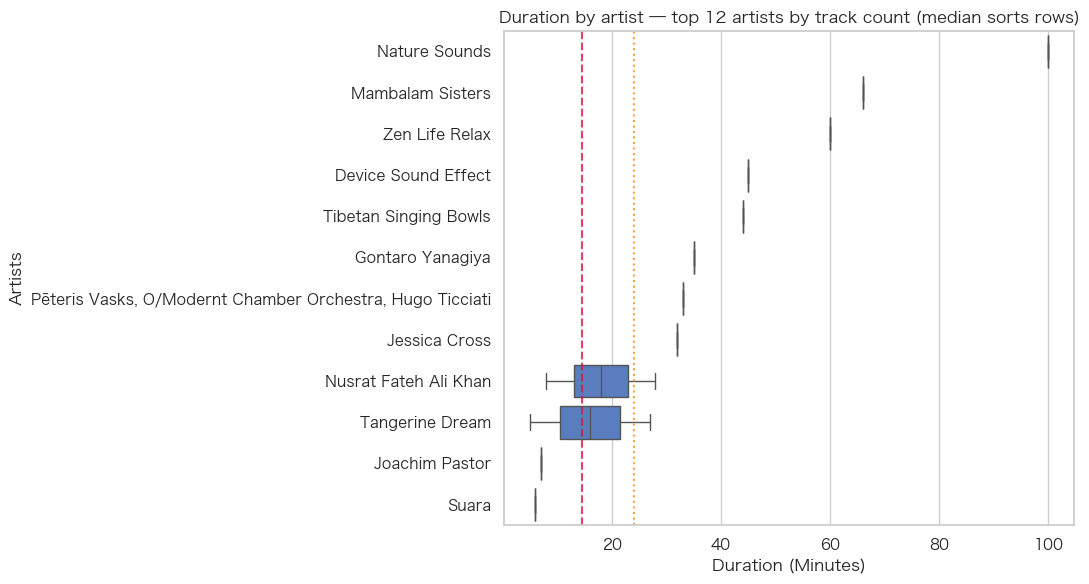

In [5]:
K = 12
top_names = df["Artists"].value_counts().head(K).index.tolist()
df_top = df[df["Artists"].isin(top_names)].copy()
order = df_top.groupby("Artists")["Duration (Minutes)"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=df_top, x="Duration (Minutes)", y="Artists", order=order, ax=ax)
ax.axvline(THRESH_EXT, color="crimson", ls="--", lw=1.5, alpha=0.8)
ax.axvline(THRESH_VLONG, color="darkorange", ls=":", lw=1.5, alpha=0.8)
ax.set_title(f"Duration by artist — top {K} artists by track count (median sorts rows)")
plt.tight_layout()
plt.show()


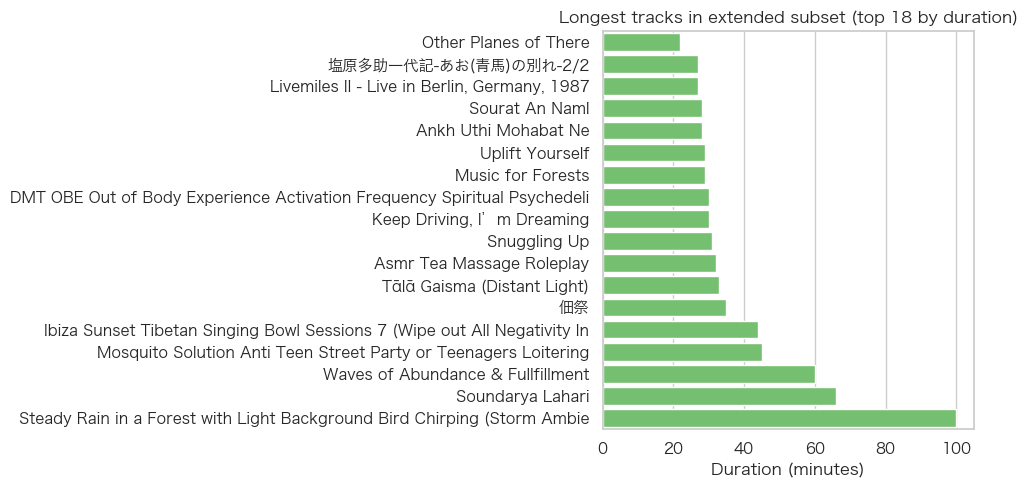

In [6]:
top_n = min(18, len(df_long))
plot_df = df_long.head(top_n).iloc[::-1].copy()
plot_df["label"] = plot_df["Name"].str.slice(0, 72)

fig, ax = plt.subplots(figsize=(10, max(4, top_n * 0.28)))
sns.barplot(data=plot_df, x="Duration (Minutes)", y="label", ax=ax, color=sns.color_palette("muted")[2])
ax.set_ylabel("")
ax.set_xlabel("Duration (minutes)")
ax.set_title(f"Longest tracks in extended subset (top {top_n} by duration)")
plt.tight_layout()
plt.show()


## 3b — Track title text (word clouds)

Tokenize **track names** (Latin words plus non‑ASCII runs so CJK/Japanese titles contribute). English stopwords plus common music boilerplate (`remix`, `feat`, …) are dropped — similar spirit to exploratory word clouds on Kaggle ([factors-of-dangerous-work](https://www.kaggle.com/code/nicapotato/factors-of-dangerous-work)).

**Agent summary:** Compare top tokens for the **full catalog** vs **`df_long`**; long‑tier titles often emphasize ambience, movement, nature, or meditation vocabulary.


findfont: Font family ['PingFang SC'] not found. Falling back to DejaVu Sans.


Top 25 tokens (full catalog): [('original', 41.0), ('op', 22.0), ('allegro', 15.0), ('de', 14.0), ('la', 14.0), ('el', 13.0), ('love', 12.0), ('minor', 11.0), ('piano', 10.0), ('en', 10.0), ('ii', 9.0), ('major', 9.0), ('vivo', 9.0), ('music', 8.0), ('symphony', 8.0), ('instrumental', 8.0), ('day', 8.0), ('molto', 7.0), ('die', 7.0), ('one', 7.0), ('sleep', 6.0), ('con', 6.0), ('high', 6.0), ('iii', 6.0), ('kapitel', 6.0)]

Top 25 tokens (extended subset): [('light', 2.0), ('music', 2.0), ('remastered', 2.0), ('symphony', 2.0), ('major', 2.0), ('allegro', 2.0), ('moderato', 2.0), ('steady', 1.0), ('rain', 1.0), ('forest', 1.0), ('background', 1.0), ('bird', 1.0), ('chirping', 1.0), ('storm', 1.0), ('ambience', 1.0), ('soundarya', 1.0), ('lahari', 1.0), ('waves', 1.0), ('abundance', 1.0), ('fullfillment', 1.0), ('mosquito', 1.0), ('solution', 1.0), ('anti', 1.0), ('teen', 1.0), ('street', 1.0)]


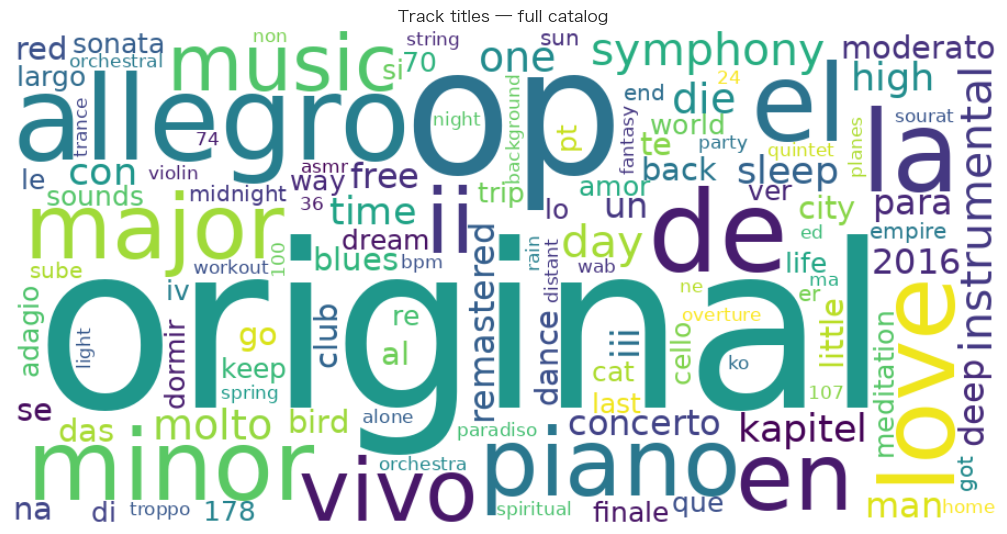

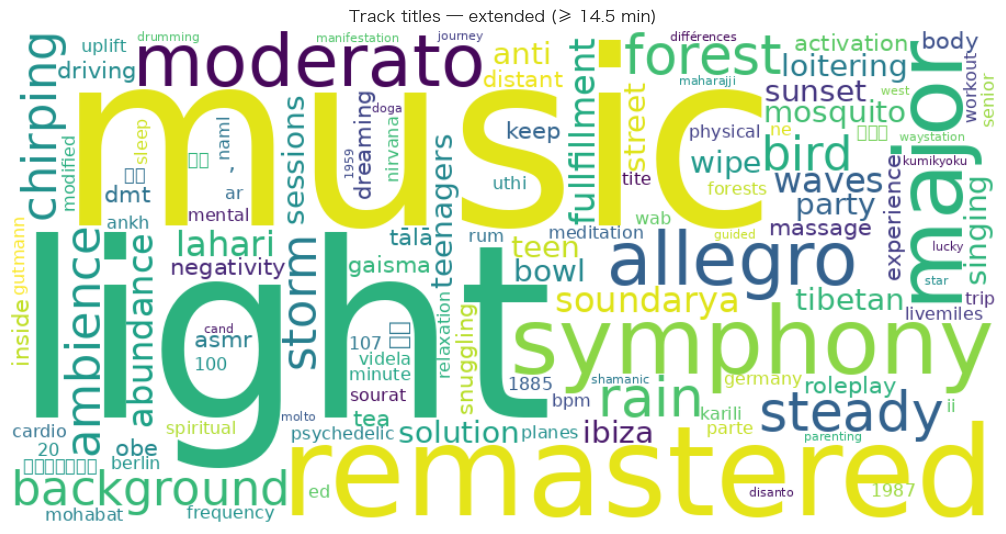

In [7]:
import re
from collections import Counter

from wordcloud import STOPWORDS, WordCloud

MUSIC_STOP = STOPWORDS | {
    "feat",
    "ft",
    "remix",
    "mix",
    "extended",
    "live",
    "version",
    "vol",
    "edit",
    "hq",
    "official",
    "audio",
    "sound",
    "effects",
}


def titles_to_wordfreq(names: pd.Series) -> dict[str, float]:
    text = " ".join(names.astype(str))
    tokens = re.findall(r"[\w']+|[^\x00-\x7F]+", text.lower())
    filtered: list[str] = []
    for t in tokens:
        if t in MUSIC_STOP:
            continue
        if len(t) == 1 and t.isascii():
            continue
        filtered.append(t)
    counts = Counter(filtered)
    return {w: float(c) for w, c in counts.items()}


def show_wordcloud(freq: dict[str, float], title: str) -> None:
    if not freq:
        print("(no tokens after stopwords)")
        return
    wc = WordCloud(
        font_path=resolve_wordcloud_font_path(),
        width=900,
        height=450,
        background_color="white",
        max_words=120,
        collocations=True,
        prefer_horizontal=0.85,
    ).generate_from_frequencies(freq)
    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


freq_all = titles_to_wordfreq(df["Name"])
freq_long = titles_to_wordfreq(df_long["Name"])

top_all = sorted(freq_all.items(), key=lambda x: x[1], reverse=True)[:25]
top_long = sorted(freq_long.items(), key=lambda x: x[1], reverse=True)[:25]
print("Top 25 tokens (full catalog):", top_all)
print("\nTop 25 tokens (extended subset):", top_long)

show_wordcloud(freq_all, "Track titles — full catalog")
show_wordcloud(freq_long, f"Track titles — extended (≥ {THRESH_EXT} min)")


## 4 — Closing synthesis (agent-readable)

- **Bulk:** Most tracks sit in a compact band (~5–15 minutes); mean is pulled upward by rare ultra-long recordings.
- **Extended tier (`≥ 14.5` min):** Small minority of rows — enumerate via `df_long` — includes ambient/soundscape-style titles.
- **Artist structure:** High artist cardinality vs rows implies limited duplication; long-tail tracks may still concentrate among a subset of creators — compare `df_long["Artists"].value_counts()` to global counts.

Re-run `make execute-spotify` after edits to validate execution under `uv`.
